In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Read summary file
norb_list, runtime_list, mol_list = [], [], []
summary = '/home/sharmagroup/sharmagroup/w4_17/w4-17_all/summary/all_vdzsd.dat'
with open(summary) as f:
    for line in f:
        parts = line.split()
        if len(parts) != 9:
            continue
        try:
            norb_list.append(int(parts[7]))
            runtime_list.append(float(parts[8]))
            mol_list.append(parts[0])
        except ValueError:
            continue

norb    = np.array(norb_list)
runtime = np.array(runtime_list)
print(f'Loaded {len(norb)} molecules')
print(f'norb range:    {norb.min()} – {norb.max()}')
print(f'runtime range: {runtime.min():.1f} – {runtime.max():.1f} s')

Loaded 200 molecules
norb range:    4 – 104
runtime range: 66.7 – 2362.1 s


In [2]:
# --- Nonlinear fit:  t = a * N^c + b ---
# c is expected to be ~5 for AFQMC (O(N^5) algorithm)

def power_law(N, a, c, b):
    return a * N**c + b

# Initial guesses: c=5, b ~ constant overhead, a from a mid-range point
b0 = runtime.min()
a0 = (np.median(runtime) - b0) / np.median(norb)**5
p0 = [a0, 5.0, b0]

popt, pcov = curve_fit(power_law, norb, runtime, p0=p0, maxfev=20000)
a_fit, c_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))

# R² on linear scale
t_pred = power_law(norb, *popt)
ss_res = np.sum((runtime - t_pred)**2)
ss_tot = np.sum((runtime - runtime.mean())**2)
r2 = 1 - ss_res / ss_tot

print(f'Nonlinear fit:  t = {a_fit:.4g} * N^c + {b_fit:.3g}')
print(f'Exponent  c  = {c_fit:.3f} ± {perr[1]:.3f}')
print(f'Prefactor a  = {a_fit:.4g} ± {perr[0]:.2g}')
print(f'Offset    b  = {b_fit:.3g} ± {perr[2]:.2g}')
print(f'R²           = {r2:.4f}')

Nonlinear fit:  t = 0.0002505 * N^c + 98.8
Exponent  c  = 3.427 ± 0.049
Prefactor a  = 0.0002505 ± 5.6e-05
Offset    b  = 98.8 ± 4.4
R²           = 0.9849


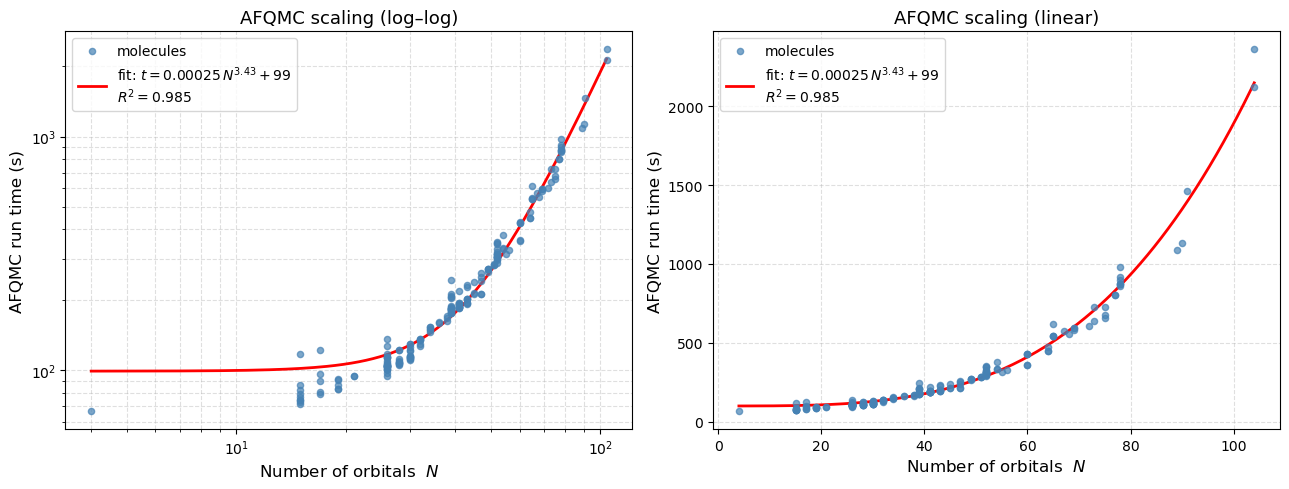

In [ ]:
# --- Main plot: log-log and linear side by side ---
N_fit = np.linspace(norb.min(), norb.max(), 300)
t_fit = power_law(N_fit, *popt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, xscale, yscale, title in [
    (axes[0], 'log', 'log', 'AFQMC scaling (log–log)'),
    (axes[1], 'linear', 'linear', 'AFQMC scaling (linear)'),
]:
    ax.scatter(norb, runtime, s=20, alpha=0.7, color='steelblue', zorder=3, label='molecules')
    ax.plot(N_fit, t_fit, 'r-', lw=2,
            label=fr'fit: $t = {a_fit:.3g}\,N^{{{c_fit:.2f}}} + {b_fit:.2g}$'
                  f'\n$R^2={r2:.3f}$')
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_xlabel('Number of orbitals  $N$', fontsize=12)
    ax.set_ylabel('AFQMC run time (s)', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, which='both', ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig('/home/sharmagroup/sharmagroup/w4_17/w4-17_all/analysis/afqmc_scaling.png', dpi=150)
plt.show()

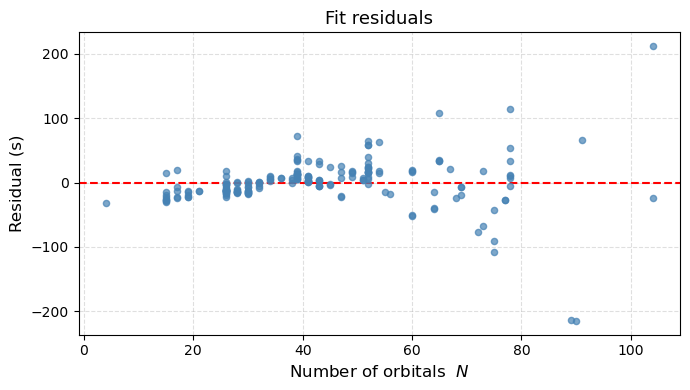

RMSE = 37.39 s


In [5]:
# --- Residuals ---
residuals = runtime - t_pred

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(norb, residuals, s=20, alpha=0.7, color='steelblue', zorder=3)
ax.axhline(0, color='r', lw=1.5, ls='--')
# ax.set_xscale('log')
ax.set_xlabel('Number of orbitals  $N$', fontsize=12)
ax.set_ylabel('Residual (s)', fontsize=12)
ax.set_title('Fit residuals', fontsize=13)
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean(residuals**2))
print(f'RMSE = {rmse:.2f} s')

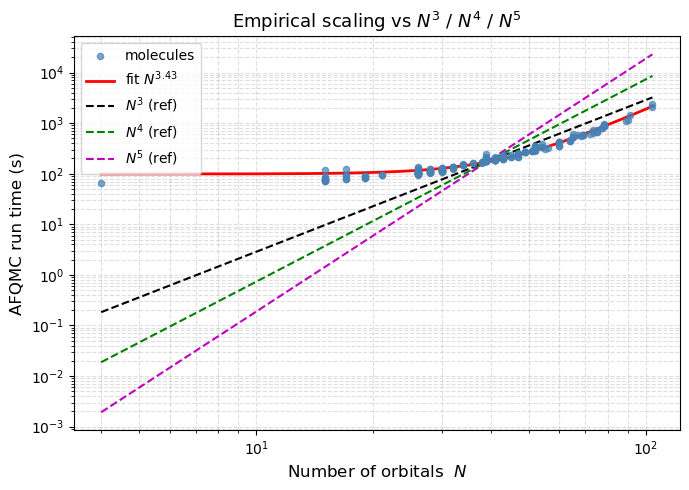

In [6]:
# --- Compare fit against N^3, N^4, N^5 reference lines ---
# Anchor reference lines at the fitted curve at the median N
N_med = np.median(norb)
t_med = power_law(N_med, *popt)
refs  = {3: 'k--', 4: 'g--', 5: 'm--'}

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(norb, runtime, s=20, alpha=0.7, color='steelblue', zorder=3, label='molecules')
ax.plot(N_fit, t_fit, 'r-', lw=2, label=fr'fit $N^{{{c_fit:.2f}}}$')
for exp, ls in refs.items():
    c_ref = t_med / N_med**exp
    ax.plot(N_fit, c_ref * N_fit**exp, ls, lw=1.5, label=f'$N^{exp}$ (ref)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of orbitals  $N$', fontsize=12)
ax.set_ylabel('AFQMC run time (s)', fontsize=12)
ax.set_title(r'Empirical scaling vs $N^3$ / $N^4$ / $N^5$', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()